# Dynamic Augmented Pooled Testing (DAPTS) — Illustrated Examples

This notebook demonstrates the key algorithms and concepts of our augmented pooled testing framework.

**Key idea**: An *augmented* pooled test returns the **exact count** $r = |t \cap Z|$ of infected individuals in pool $t$, rather than just a binary positive/negative result.

In [ ]:
import sys, os
# Add repo root to path (two levels up from notebooks/)
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

from augmented.core import (
    mask_from_indices, indices_from_mask, mask_str,
    test_result, all_pools, popcount,
)
from augmented.bayesian import (
    bayesian_update_single_test, bayesian_update,
    bayesian_update_by_counting, gibbs_update,
)
from augmented.greedy import (
    greedy_myopic_simulate, greedy_myopic_expected_utility,
    greedy_myopic_counting_simulate, greedy_myopic_counting_expected_utility,
    greedy_myopic_gibbs_simulate, greedy_myopic_gibbs_expected_utility,
)
from augmented.solver import solve_optimal_dapts
from augmented.classical_solver import solve_classical_dynamic
from augmented.baselines import u_max, u_single
from augmented.comparison import compare_all
from augmented.tree_extractor import extract_tree, print_tree

matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12
print('All imports OK')

---
## 1. Basic Concepts: Pools, Tests, and Bitmasks

Each individual is represented as a bit in an integer bitmask. A pool is a subset of individuals.

In [20]:
n = 5  # population size

# Create pools using bitmasks
pool_A = mask_from_indices([0, 1, 2])  # individuals {0, 1, 2}
pool_B = mask_from_indices([2, 3, 4])  # individuals {2, 3, 4}

# Suppose the true infection profile is: individuals 1 and 3 are infected
z_mask = mask_from_indices([1, 3])

# Augmented test results give the EXACT COUNT of infected
r_A = test_result(pool_A, z_mask)  # |{0,1,2} ∩ {1,3}| = |{1}| = 1
r_B = test_result(pool_B, z_mask)  # |{2,3,4} ∩ {1,3}| = |{3}| = 1

print(f'Population: n = {n}')
print(f'True infection: Z = {mask_str(z_mask, n)} (individuals {indices_from_mask(z_mask, n)})')
print(f'Pool A = {mask_str(pool_A, n)} → r = {r_A} (1 of 3 infected)')
print(f'Pool B = {mask_str(pool_B, n)} → r = {r_B} (1 of 3 infected)')
print()
print('Compare with CLASSICAL (binary) test:')
print(f'Pool A → {"POSITIVE" if r_A > 0 else "NEGATIVE"} (at least 1 infected)')
print(f'Pool B → {"POSITIVE" if r_B > 0 else "NEGATIVE"} (at least 1 infected)')
print()
print('The augmented test tells us HOW MANY are infected, not just whether any are.')

Population: n = 5
True infection: Z = {1,3} (individuals [1, 3])
Pool A = {0,1,2} → r = 1 (1 of 3 infected)
Pool B = {2,3,4} → r = 1 (1 of 3 infected)

Compare with CLASSICAL (binary) test:
Pool A → POSITIVE (at least 1 infected)
Pool B → POSITIVE (at least 1 infected)

The augmented test tells us HOW MANY are infected, not just whether any are.


---
## 2. Three Bayesian Update Methods Compared

After observing test results, we update infection probabilities. We have three methods:

1. **Sequential**: Updates per-test using Poisson-Binomial — fast but misses cross-test info
2. **Counting**: Enumerates all 2^n profiles — exact but O(2^n)
3. **Gibbs Sampling**: MCMC approximation — scalable and captures cross-test info

In [21]:
# Setup: 3 individuals, overlapping pools
n = 3
p = [0.3, 0.3, 0.3]  # prior: each 30% chance of infection

# Test 1: pool {0, 1}, result = 1 (exactly 1 of the 2 is infected)
# Test 2: pool {1, 2}, result = 0 (both are healthy)
history = (
    (mask_from_indices([0, 1]), 1),
    (mask_from_indices([1, 2]), 0),
)

print('Prior probabilities:', p)
print('Test 1: pool {0,1}, r=1 → exactly 1 infected')
print('Test 2: pool {1,2}, r=0 → both healthy')
print()

# What can we LOGICALLY deduce?
print('LOGICAL DEDUCTION:')
print('  Test 2 says: agents 1 and 2 are healthy → P(Z_1)=0, P(Z_2)=0')
print('  Test 1 says: exactly 1 of {0,1} infected. Since agent 1 is healthy...')
print('  → Agent 0 MUST be infected: P(Z_0)=1.0')
print()
print('  Correct posterior: [1.0, 0.0, 0.0]')

Prior probabilities: [0.3, 0.3, 0.3]
Test 1: pool {0,1}, r=1 → exactly 1 infected
Test 2: pool {1,2}, r=0 → both healthy

LOGICAL DEDUCTION:
  Test 2 says: agents 1 and 2 are healthy → P(Z_1)=0, P(Z_2)=0
  Test 1 says: exactly 1 of {0,1} infected. Since agent 1 is healthy...
  → Agent 0 MUST be infected: P(Z_0)=1.0

  Correct posterior: [1.0, 0.0, 0.0]


In [22]:
# Compare the three methods
# (Redefine variables to be cell-independent)
n = 3
p = [0.3, 0.3, 0.3]
history = (
    (mask_from_indices([0, 1]), 1),
    (mask_from_indices([1, 2]), 0),
)

seq = bayesian_update(p, history, n)
cnt = bayesian_update_by_counting(p, history, n)
gbs = gibbs_update(p, history, n, num_iterations=2000, seed=42)

print(f'{"Agent":>8} {"Prior":>8} {"Sequential":>12} {"Counting":>12} {"Gibbs":>12} {"Correct":>10}')
print('-' * 65)
correct = [1.0, 0.0, 0.0]
for i in range(n):
    print(f'{i:>8} {p[i]:>8.2f} {seq[i]:>12.4f} {cnt[i]:>12.4f} {gbs[i]:>12.4f} {correct[i]:>10.1f}')

print()
print('KEY FINDING: Sequential gives P(Z_0)={:.4f} — it MISSES the cross-test'.format(seq[0]))
print('deduction because agent 0 is NOT in Test 2. Counting and Gibbs get it right.')

   Agent    Prior   Sequential     Counting        Gibbs    Correct
-----------------------------------------------------------------
       0     0.30       0.5000       1.0000       1.0000        1.0
       1     0.30       0.0000       0.0000       0.0000        0.0
       2     0.30       0.0000       0.0000       0.0000        0.0

KEY FINDING: Sequential gives P(Z_0)=0.5000 — it MISSES the cross-test
deduction because agent 0 is NOT in Test 2. Counting and Gibbs get it right.


In [23]:
# Visual comparison
# (Redefine to be cell-independent)
n = 3
p = [0.3, 0.3, 0.3]
history = (
    (mask_from_indices([0, 1]), 1),
    (mask_from_indices([1, 2]), 0),
)
seq = bayesian_update(p, history, n)
cnt = bayesian_update_by_counting(p, history, n)
gbs = gibbs_update(p, history, n, num_iterations=2000, seed=42)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(n)
width = 0.2

bars1 = ax.bar(x - 1.5*width, p, width, label='Prior', color='lightgray', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, seq, width, label='Sequential', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, cnt, width, label='Counting (exact)', color='#2ecc71', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, gbs, width, label='Gibbs (MCMC)', color='#3498db', edgecolor='black')

ax.set_xlabel('Agent')
ax.set_ylabel('P(infected)')
ax.set_title('Cross-Test Information: Sequential Misses What Counting & Gibbs Capture')
ax.set_xticks(x)
ax.set_xticklabels([f'Agent {i}' for i in range(n)])
ax.legend()
ax.set_ylim(0, 1.15)

# Annotate the key difference
ax.annotate('Sequential misses\ncross-test info!', xy=(0 - 0.5*width, seq[0]),
            xytext=(0.8, 0.7), fontsize=11, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.close(fig)

---
## 3. Gibbs Sampling: How It Converges

The Gibbs sampler iterates over agents, sampling each one conditional on all others. Let's visualize convergence.

In [24]:
# Larger example to see convergence
n = 5
p = [0.2, 0.3, 0.15, 0.25, 0.1]
history = (
    (mask_from_indices([0, 1, 2]), 1),  # exactly 1 of {0,1,2} infected
    (mask_from_indices([2, 3, 4]), 0),  # none of {2,3,4} infected
)

# Get exact values for reference
exact = bayesian_update_by_counting(p, history, n)

# Run Gibbs with increasing iterations and track estimates
iteration_counts = [50, 100, 200, 500, 1000, 2000, 5000]
estimates = {}
for num_iter in iteration_counts:
    est = gibbs_update(p, history, n, num_iterations=num_iter, burn_in=num_iter//5, seed=42)
    estimates[num_iter] = est

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, n))

for i in range(n):
    errors = [abs(estimates[k][i] - exact[i]) for k in iteration_counts]
    axes[0].plot(iteration_counts, errors, 'o-', color=colors[i], label=f'Agent {i}')

axes[0].set_xlabel('Number of Iterations')
axes[0].set_ylabel('|Gibbs - Exact|')
axes[0].set_title('Gibbs Convergence to Exact Posterior')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Compare final estimates
x = np.arange(n)
width = 0.35
axes[1].bar(x - width/2, exact, width, label='Exact (counting)', color='#2ecc71', edgecolor='black')
axes[1].bar(x + width/2, estimates[5000], width, label='Gibbs (5000 iter)', color='#3498db', edgecolor='black')
axes[1].set_xlabel('Agent')
axes[1].set_ylabel('P(infected)')
axes[1].set_title('Gibbs vs Exact Posterior (5000 iterations)')
axes[1].set_xticks(x)
axes[1].legend()

plt.tight_layout()
plt.close(fig)

print('\nExact posteriors:', [f'{v:.4f}' for v in exact])
print('Gibbs (5000):   ', [f'{v:.4f}' for v in estimates[5000]])


Exact posteriors: ['0.3684', '0.6316', '0.0000', '0.0000', '0.0000']
Gibbs (5000):    ['0.3739', '0.6261', '0.0000', '0.0000', '0.0000']


---
## 4. Strategy Comparison: The Inequality Chain

The theoretical result guarantees:

$$U^{\text{single}} \leq U^{s}_{\text{NO}} \leq U^{s}_{\text{O}} \leq U^D \leq U^D_A \leq U^{\max}$$

Let's verify this and see where each strategy falls.

In [25]:
# Test instance
p = [0.05, 0.10, 0.15, 0.20, 0.08]
u = [4.0, 6.0, 3.0, 5.0, 7.0]
B, G = 2, 3
n = len(p)

results = compare_all(p, u, B, G)

# Ordered strategies
strategies = [
    ('Individual\nTests', 'U_single'),
    ('Static\nNon-Overlapping', 'U_s_NO'),
    ('Static\nOverlapping', 'U_s_O'),
    ('Dynamic\nClassical', 'U_D'),
    ('Dynamic\nAugmented', 'U_D_A'),
    ('Upper\nBound', 'U_max'),
]

greedy_strategies = [
    ('Greedy\nSequential', 'U_greedy'),
    ('Greedy\nCounting', 'U_greedy_counting'),
    ('Greedy\nGibbs', 'U_greedy_gibbs'),
]

fig, ax = plt.subplots(figsize=(14, 6))

# Main chain
labels = [s[0] for s in strategies]
values = [results[s[1]] for s in strategies]
colors_chain = ['#95a5a6', '#e67e22', '#e67e22', '#2980b9', '#27ae60', '#7f8c8d']
bars = ax.bar(range(len(strategies)), values, color=colors_chain, edgecolor='black', alpha=0.85)

# Greedy strategies as horizontal lines
greedy_colors = ['#e74c3c', '#8e44ad', '#f39c12']
for idx, (label, key) in enumerate(greedy_strategies):
    ax.axhline(y=results[key], color=greedy_colors[idx], linestyle='--', linewidth=2,
               label=f'{label.replace(chr(10), " ")}: {results[key]:.4f}')

ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Expected Utility')
ax.set_title(f'Strategy Comparison — n={n}, B={B}, G={G}')
ax.legend(loc='lower right')

# Value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.close(fig)

print(f'Augmented benefit over classical: +{(results["U_D_A"] - results["U_D"]) / results["U_D"] * 100:.2f}%')

Augmented benefit over classical: +0.28%


---
## 5. Decision Tree: Visualizing the Optimal Strategy

The optimal DAPTS strategy is a decision tree where each node represents a test and branches correspond to possible outcomes.

In [26]:
p = [0.1, 0.2, 0.3]
u = [5.0, 3.0, 4.0]
B, G = 2, 2
n = len(p)

val, policy = solve_optimal_dapts(p, u, B, G)
tree = extract_tree(policy, p, u, n)

print(f'Optimal expected utility: {val:.4f}')
print(f'\nDecision tree (B={B}, G={G}):')
print('=' * 50)
print_tree(tree, n)
print()
print('Reading the tree:')
print('  - "Test {i,j}" means pool these individuals together')
print('  - "r=0" means all healthy → clear them (gain utility)')
print('  - "r=1" means 1 infected → cannot clear, use next test wisely')
print('  - "r=2" means both infected → cannot clear either')

Optimal expected utility: 8.9820

Decision tree (B=2, G=2):
Step 1: test pool {0,2} | cleared={} | p=[0.100, 0.200, 0.300]
  r=0:
    Step 2: test pool {1} | cleared={0,2} | p=[0.000, 0.200, 0.000]
      r=0:
        [TERMINAL] cleared={0,1,2} utility=12.00 posteriors=[0.000, 0.000, 0.000]
      r=1:
        [TERMINAL] cleared={0,2} utility=9.00 posteriors=[0.000, 1.000, 0.000]
  r=1:
    Step 2: test pool {0,1} | cleared={} | p=[0.206, 0.200, 0.794]
      r=0:
        [TERMINAL] cleared={0,1} utility=8.00 posteriors=[0.000, 0.000, 0.794]
      r=1:
        [TERMINAL] cleared={} utility=0.00 posteriors=[0.509, 0.491, 0.794]
      r=2:
        [TERMINAL] cleared={} utility=0.00 posteriors=[1.000, 1.000, 0.794]
  r=2:
    Step 2: test pool {1} | cleared={} | p=[1.000, 0.200, 1.000]
      r=0:
        [TERMINAL] cleared={1} utility=3.00 posteriors=[1.000, 0.000, 1.000]
      r=1:
        [TERMINAL] cleared={} utility=0.00 posteriors=[1.000, 1.000, 1.000]

Reading the tree:
  - "Test {i,j}

### Visual Decision Tree (Graphviz)

Render the decision tree as a colored graph using Graphviz. Blue nodes are decision points (tests), green nodes are terminal outcomes.

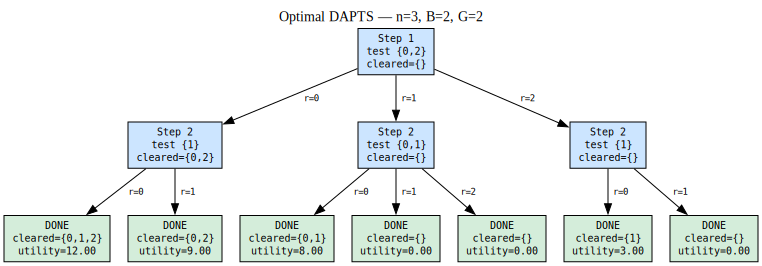

In [27]:
from augmented.tree_extractor import export_tree_dot

# Reuse the tree from the cell above
p_tree = [0.1, 0.2, 0.3]
u_tree = [5.0, 3.0, 4.0]
B_tree, G_tree = 2, 2
n_tree = len(p_tree)

val_tree, policy_tree = solve_optimal_dapts(p_tree, u_tree, B_tree, G_tree)
tree_viz = extract_tree(policy_tree, p_tree, u_tree, n_tree)
dot_str = export_tree_dot(tree_viz, n_tree, title=f'Optimal DAPTS — n={n_tree}, B={B_tree}, G={G_tree}')

try:
    import graphviz
    display(graphviz.Source(dot_str))
except ImportError:
    print('graphviz Python package not installed. Install with: pip install graphviz')
    print('You can also save and render manually:')
    print('  1. Save dot_str to a file: tree.dot')
    print('  2. Run: dot -Tpng tree.dot -o tree.png')
    print()
    print('DOT source (first 500 chars):')
    print(dot_str[:500])

---
## 6. Greedy Simulation: Watching a Strategy Execute

Let's watch the greedy strategy execute step-by-step on specific infection profiles.

In [28]:
p = [0.1, 0.2, 0.15, 0.25, 0.05]
u = [4.0, 6.0, 3.0, 5.0, 7.0]
B, G = 3, 3
n = len(p)

# Simulate on different infection profiles
profiles = [
    (0, 'Nobody infected'),
    (mask_from_indices([1]), 'Only agent 1 infected'),
    (mask_from_indices([1, 3]), 'Agents 1 and 3 infected'),
    (mask_from_indices([0, 1, 2, 3, 4]), 'Everyone infected'),
]

print(f'Population: n={n}, Budget: B={B}, Max pool: G={G}')
print(f'Priors:    p = {p}')
print(f'Utilities: u = {u}')
print()

for z_mask, desc in profiles:
    print(f'--- {desc}: Z = {mask_str(z_mask, n)} ---')
    
    # Sequential greedy
    hist_s, cleared_s, util_s = greedy_myopic_simulate(p, u, B, G, z_mask)
    
    # Counting greedy
    hist_c, cleared_c, util_c = greedy_myopic_counting_simulate(p, u, B, G, z_mask)
    
    # Gibbs greedy
    hist_g, cleared_g, util_g = greedy_myopic_gibbs_simulate(
        p, u, B, G, z_mask, seed=42)
    
    for step, (pool, r) in enumerate(hist_s):
        pool_str = '{' + ','.join(str(i) for i in indices_from_mask(pool, n)) + '}'
        print(f'  Step {step+1}: Test {pool_str} → r={r}' + 
              (' → CLEAR!' if r == 0 else ''))
    
    cleared_agents = indices_from_mask(cleared_s, n)
    print(f'  Cleared: {cleared_agents}, Utility: {util_s:.1f} / {sum(u):.1f}')
    
    if util_c != util_s:
        print(f'  [Counting greedy: {util_c:.1f}, Gibbs greedy: {util_g:.1f}]')
    print()

Population: n=5, Budget: B=3, Max pool: G=3
Priors:    p = [0.1, 0.2, 0.15, 0.25, 0.05]
Utilities: u = [4.0, 6.0, 3.0, 5.0, 7.0]

--- Nobody infected: Z = {} ---
  Step 1: Test {0,1,4} → r=0 → CLEAR!
  Step 2: Test {2,3} → r=0 → CLEAR!
  Cleared: [0, 1, 2, 3, 4], Utility: 25.0 / 25.0

--- Only agent 1 infected: Z = {1} ---
  Step 1: Test {0,1,4} → r=1
  Step 2: Test {2,3,4} → r=0 → CLEAR!
  Step 3: Test {0} → r=0 → CLEAR!
  Cleared: [0, 2, 3, 4], Utility: 19.0 / 25.0

--- Agents 1 and 3 infected: Z = {1,3} ---
  Step 1: Test {0,1,4} → r=1
  Step 2: Test {2,3,4} → r=1
  Step 3: Test {0,4} → r=0 → CLEAR!
  Cleared: [0, 4], Utility: 11.0 / 25.0

--- Everyone infected: Z = {0,1,2,3,4} ---
  Step 1: Test {0,1,4} → r=3
  Step 2: Test {2,3} → r=2
  Cleared: [], Utility: 0.0 / 25.0



---
## 7. Scalability: Gibbs vs Counting

The key advantage of Gibbs sampling is scalability. Let's measure runtime as n grows.

In [39]:
import time

sizes = [4, 6, 8, 10, 12, 14, 16, 18, 20]
counting_times = []
gibbs_times = []

for n in sizes:
    p = [0.15] * n
    # One test: pool of first min(n, 5) agents with r=1
    pool = mask_from_indices(list(range(min(n, 5))))
    history = ((pool, 1),)
    
    # Counting
    t0 = time.time()
    cnt = bayesian_update_by_counting(p, history, n)
    counting_times.append(time.time() - t0)
    
    # Gibbs
    t0 = time.time()
    gbs = gibbs_update(p, history, n, num_iterations=1000, seed=42)
    gibbs_times.append(time.time() - t0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, counting_times, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='Counting (exact, O(2^n))')
ax.plot(sizes, gibbs_times, 's-', color='#3498db', linewidth=2, markersize=8, label='Gibbs (MCMC, O(n))')
ax.set_xlabel('Population size n')
ax.set_ylabel('Time (seconds)')
ax.set_title('Runtime: Counting vs Gibbs Sampling')
ax.set_yscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.close(fig)

print(f'At n={sizes[-1]}:')
print(f'  Counting: {counting_times[-1]:.4f}s')
print(f'  Gibbs:    {gibbs_times[-1]:.4f}s')
print(f'  Speedup:  {counting_times[-1]/gibbs_times[-1]:.1f}x')

At n=20:
  Counting: 0.3590s
  Gibbs:    0.0046s
  Speedup:  78.3x


---
## 8. Augmented vs Classical: When Does Augmented Information Help?

The augmented test provides more information (exact count vs binary). Let's see when this matters.

In [30]:
import random
random.seed(42)

# Generate random instances and measure augmented benefit
benefits = []
p_avgs = []
n = 5
B, G = 2, 3

for _ in range(200):
    p = [random.uniform(0.05, 0.5) for _ in range(n)]
    u = [random.uniform(1, 10) for _ in range(n)]
    
    val_classical, _ = solve_classical_dynamic(p, u, B, G)
    val_augmented, _ = solve_optimal_dapts(p, u, B, G)
    
    if val_classical > 1e-10:
        benefit = (val_augmented - val_classical) / val_classical * 100
        benefits.append(benefit)
        p_avgs.append(sum(p) / len(p))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of benefits
axes[0].hist(benefits, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(x=np.mean(benefits), color='red', linestyle='--', linewidth=2,
                label=f'Mean: +{np.mean(benefits):.2f}%')
axes[0].set_xlabel('Augmented Benefit (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Augmented Benefit over Classical')
axes[0].legend()

# Scatter: benefit vs average infection rate
axes[1].scatter(p_avgs, benefits, alpha=0.5, color='#e74c3c', s=30)
axes[1].set_xlabel('Average Infection Rate')
axes[1].set_ylabel('Augmented Benefit (%)')
axes[1].set_title('Benefit Increases with Infection Rate')
axes[1].grid(True, alpha=0.3)

# Trend line
z = np.polyfit(p_avgs, benefits, 1)
trend = np.poly1d(z)
x_trend = np.linspace(min(p_avgs), max(p_avgs), 100)
axes[1].plot(x_trend, trend(x_trend), 'b--', linewidth=2, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.close(fig)

print(f'Augmented benefit: mean={np.mean(benefits):.2f}%, max={max(benefits):.2f}%')
print(f'Instances where augmented helps: {sum(1 for b in benefits if b > 0.01)}/{len(benefits)}')

Augmented benefit: mean=1.57%, max=6.02%
Instances where augmented helps: 191/200


---
## 9. Gibbs Sampling Internals: Swap Moves for Ergodicity

Standard Gibbs sampling can get **stuck** with exact-count constraints. With pool {0,1,2} and r=1, if agent 0 is infected, standard Gibbs can never swap to agent 1 being infected (going through 0 or 2 infected violates r=1).

Our implementation adds **swap moves** (Metropolis-Hastings within Gibbs) to ensure proper mixing.

In [31]:
# Demo: pool of 4 with r=1 — who is the infected one?
n = 4
p = [0.1, 0.4, 0.2, 0.3]  # Agent 1 most likely, agent 0 least
history = ((mask_from_indices([0, 1, 2, 3]), 1),)  # exactly 1 infected

exact = bayesian_update_by_counting(p, history, n)

# Run Gibbs with different iteration counts
iters_list = [100, 500, 1000, 3000, 10000]
results_gibbs = {}
for num_iter in iters_list:
    results_gibbs[num_iter] = gibbs_update(
        p, history, n, num_iterations=num_iter, burn_in=num_iter//5, seed=42)

print('Pool {0,1,2,3}, r=1: exactly 1 infected')
print(f'Priors: {p}')
print(f'Exact posteriors: {[f"{v:.4f}" for v in exact]}')
print()
print('Agent 1 (prior=0.4) should have highest posterior.')
print('Without swap moves, Gibbs would stay stuck at whichever agent was initially infected.')
print()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n)
width = 0.12

ax.bar(x - 2.5*width, exact, width, label='Exact', color='#2ecc71', edgecolor='black')
colors_g = ['#d5dbdb', '#aab7b8', '#7f8c8d', '#566573', '#2c3e50']
for idx, num_iter in enumerate(iters_list):
    ax.bar(x + (idx-1.5)*width, results_gibbs[num_iter], width,
           label=f'Gibbs {num_iter}', color=colors_g[idx], edgecolor='black')

ax.set_xlabel('Agent')
ax.set_ylabel('P(infected | r=1)')
ax.set_title('Gibbs with Swap Moves Converges to Exact Posterior')
ax.set_xticks(x)
ax.set_xticklabels([f'Agent {i}\n(prior={p[i]})' for i in range(n)])
ax.legend(fontsize=9)

plt.tight_layout()
plt.close(fig)

Pool {0,1,2,3}, r=1: exactly 1 infected
Priors: [0.1, 0.4, 0.2, 0.3]
Exact posteriors: ['0.0763', '0.4578', '0.1717', '0.2943']

Agent 1 (prior=0.4) should have highest posterior.
Without swap moves, Gibbs would stay stuck at whichever agent was initially infected.



---
## 10. Summary: The Three Posterior Update Methods

| Method | Complexity | Cross-Test Info | Best For |
|--------|-----------|----------------|----------|
| **Sequential** | O(G) per test | Misses it | Real-time, large n |
| **Counting** | O(2^n) | Exact | Small n (≤20), validation |
| **Gibbs Sampling** | O(nG × iters) | Approximate | Medium-large n (20-50+) |

The **Gibbs sampler with swap moves** fills the gap between fast-but-lossy sequential updates and exact-but-exponential counting.

---
## 11. B>=3 Sequential vs Counting Divergence

For **B=2**, the sequential and counting greedy strategies are **identical** because there is no cross-test information to exploit — each test is evaluated independently. However, for **B>=3**, they **diverge**: the counting-based greedy can leverage information from earlier tests when selecting the next pool, while sequential cannot.

This section runs a comparison across B values and visualizes the mean divergence.


  B=2: evaluating 30 instances (n=5, G=3)...
    sample 25/30

  B=3: evaluating 30 instances (n=5, G=3)...
    sample 25/30

  B=4: evaluating 30 instances (n=5, G=3)...
    sample 25/30


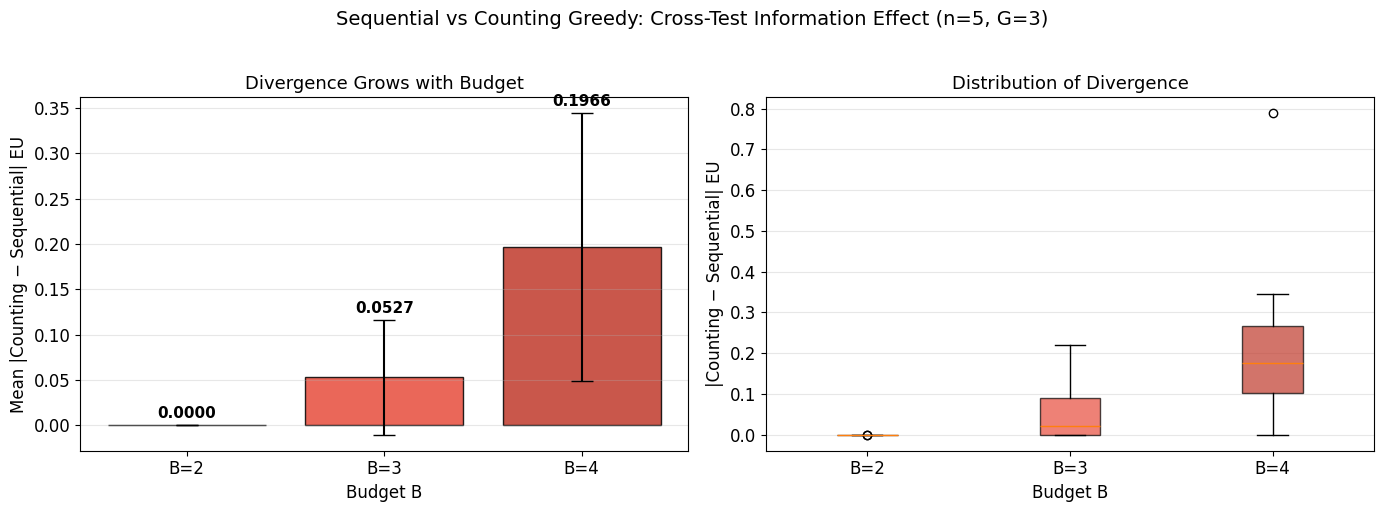

Absolute divergence by B (how much the two strategies DIFFER):
  B=2: mean |diff|=0.000000, std=0.000000, max=0.000000, instances that differ: 0/30
  B=3: mean |diff|=0.052727, std=0.063117, max=0.219345, instances that differ: 19/30
  B=4: mean |diff|=0.196550, std=0.147453, max=0.788400, instances that differ: 29/30


In [38]:
from augmented.csv_experiments import run_b_comparison
import matplotlib.pyplot as plt
import numpy as np

# Compare sequential vs counting greedy across B values
# run_b_comparison returns a DataFrame with columns: B, seq_count_diff, etc.
df_b = run_b_comparison(n=5, B_values=[2, 3, 4], G=3, num_samples=30, seed=42)

# Compute absolute divergence (how much they DIFFER, regardless of direction)
df_b['abs_divergence'] = df_b['seq_count_diff'].abs()

B_values = sorted(df_b['B'].unique())
stats = df_b.groupby('B')['abs_divergence'].agg(['mean', 'std', 'max'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of mean absolute divergence with error bars
ax = axes[0]
colors_bar = ['#95a5a6', '#e74c3c', '#c0392b'][:len(B_values)]
x_pos = range(len(B_values))
means = [stats.loc[b, 'mean'] for b in B_values]
stds = [stats.loc[b, 'std'] for b in B_values]
bars = ax.bar(x_pos, means, yerr=stds,
              color=colors_bar, edgecolor='black', capsize=8, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'B={b}' for b in B_values])
ax.set_xlabel('Budget B', fontsize=12)
ax.set_ylabel('Mean |Counting − Sequential| EU', fontsize=12)
ax.set_title('Divergence Grows with Budget', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, val, sd) in enumerate(zip(bars, means, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, val + sd + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: Box plot of absolute divergence distribution
ax = axes[1]
box_data = [df_b[df_b['B'] == b]['abs_divergence'].values for b in B_values]
bp = ax.boxplot(box_data, tick_labels=[f'B={b}' for b in B_values], patch_artist=True)
for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel('Budget B', fontsize=12)
ax.set_ylabel('|Counting − Sequential| EU', fontsize=12)
ax.set_title('Distribution of Divergence', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Sequential vs Counting Greedy: Cross-Test Information Effect (n=5, G=3)',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('_tmp_divergence.png', dpi=100, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image, display
display(Image('_tmp_divergence.png'))

print('Absolute divergence by B (how much the two strategies DIFFER):')
for b in B_values:
    data = df_b[df_b['B'] == b]['abs_divergence']
    print(f'  B={b}: mean |diff|={data.mean():.6f}, std={data.std():.6f}, '
          f'max={data.max():.6f}, instances that differ: {(data > 1e-10).sum()}/{len(data)}')

---
## 12. Semi-Utility Meta-Parameter

The **semi-utility** framework introduces a parameter **alpha** that interpolates between two extremes:
- **alpha=0**: Binary utility — an agent is either cleared (full utility) or not (zero utility)
- **alpha=1**: Posterior-based utility — utility is weighted by the posterior probability of being healthy

Intermediate values of alpha blend these two approaches. This lets decision-makers tune how aggressively they want to act on partial information.

In [40]:
from augmented.semi_utility import semi_utility, greedy_myopic_semi_expected_utility
import matplotlib.pyplot as plt
import numpy as np

# Fixed instance
p = [0.15, 0.25, 0.1, 0.3]
u = [5.0, 3.0, 4.0, 6.0]
B = 2
G = 2
n = len(p)

# Sweep alpha values
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
eu_values = []

for alpha in alphas:
    eu = greedy_myopic_semi_expected_utility(p, u, B, G, alpha=alpha)
    eu_values.append(eu)
    print(f'alpha={alpha:.2f} -> Expected Semi-Utility = {eu:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas, eu_values, 'o-', color='#8e44ad', linewidth=2.5, markersize=10)
ax.fill_between(alphas, eu_values, alpha=0.15, color='#8e44ad')
ax.set_xlabel('Alpha (0=binary, 1=posterior-based)', fontsize=12)
ax.set_ylabel('Expected Semi-Utility', fontsize=12)
ax.set_title(f'Semi-Utility vs Alpha — p={p}, u={u}, B={B}, G={G}', fontsize=13)
ax.grid(True, alpha=0.3)

for a, v in zip(alphas, eu_values):
    ax.annotate(f'{v:.3f}', (a, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)

plt.tight_layout()
plt.close(fig)

print(f'\nAs alpha increases from 0 to 1, the strategy shifts from')
print(f'purely binary clearing to posterior-weighted utility.')

alpha=0.00 -> Expected Semi-Utility = 11.6100
alpha=0.25 -> Expected Semi-Utility = 11.6100
alpha=0.50 -> Expected Semi-Utility = 11.6100
alpha=0.75 -> Expected Semi-Utility = 11.6100
alpha=1.00 -> Expected Semi-Utility = 7.8500

As alpha increases from 0 to 1, the strategy shifts from
purely binary clearing to posterior-weighted utility.


---
## 13. High Infection Rate Analysis

**Francisco's hypothesis**: The augmented benefit over classical testing should be **largest** when infection rates are high. When most people are infected, the exact count from an augmented test provides much more discriminating power than a simple positive/negative result.

This section tests this hypothesis by comparing augmented vs classical performance across different infection rate regimes.


  n=5, B=2, G=3, regime=low (p∈[0.05,0.15])...

  n=5, B=2, G=3, regime=medium (p∈[0.15,0.35])...

  n=5, B=2, G=3, regime=high (p∈[0.35,0.55])...

  n=5, B=2, G=3, regime=very_high (p∈[0.55,0.8])...


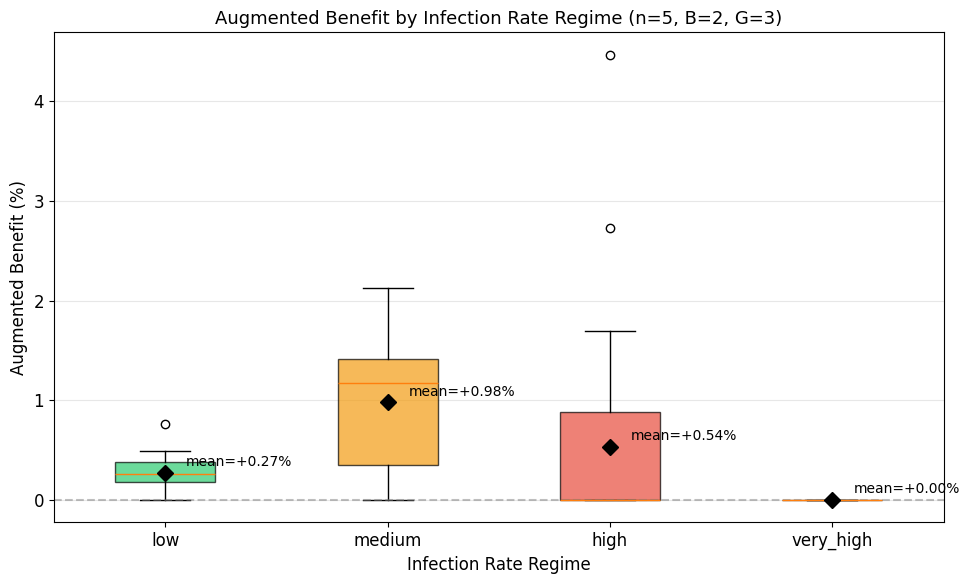

low         : mean=+0.270%, median=+0.266%, max=+0.761%, n=30
medium      : mean=+0.979%, median=+1.170%, max=+2.125%, n=30
high        : mean=+0.536%, median=+0.000%, max=+4.463%, n=30
very_high   : mean=+0.000%, median=+0.000%, max=+0.000%, n=30


In [34]:
from augmented.csv_experiments import run_high_infection_experiment
import matplotlib.pyplot as plt
import numpy as np

# Run high infection rate experiment
# Returns a DataFrame with columns: regime, augmented_benefit, etc.
df_hi = run_high_infection_experiment(n_values=[5], B_values=[2], G=3, num_samples=30, seed=42)

# Box plot grouped by regime
regime_order = ['low', 'medium', 'high', 'very_high']
regimes_present = [r for r in regime_order if r in df_hi['regime'].values]
box_data = [df_hi[df_hi['regime'] == r]['augmented_benefit'].dropna().values
            for r in regimes_present]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(box_data, tick_labels=regimes_present, patch_artist=True)

colors_box = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box[:len(regimes_present)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Infection Rate Regime', fontsize=12)
ax.set_ylabel('Augmented Benefit (%)', fontsize=12)
ax.set_title('Augmented Benefit by Infection Rate Regime (n=5, B=2, G=3)', fontsize=13)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add mean markers
for i, regime in enumerate(regimes_present):
    data = df_hi[df_hi['regime'] == regime]['augmented_benefit'].dropna()
    if len(data) > 0:
        mean_val = data.mean()
        ax.plot(i + 1, mean_val, 'D', color='black', markersize=8, zorder=5)
        ax.annotate(f'mean={mean_val:+.2f}%', (i + 1, mean_val),
                    textcoords='offset points', xytext=(15, 5), fontsize=10)

plt.tight_layout()
fig.savefig('_tmp_high_infection.png', dpi=100, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image, display
display(Image('_tmp_high_infection.png'))

for regime in regimes_present:
    data = df_hi[df_hi['regime'] == regime]['augmented_benefit'].dropna()
    if len(data) > 0:
        print(f'{regime:12s}: mean={data.mean():+.3f}%, median={data.median():+.3f}%, max={data.max():+.3f}%, n={len(data)}')

---
## 14. Tree Pruning for Large Trees

Decision trees grow exponentially with the budget B and pool size G. For visualization and analysis, we often need to **prune** the tree to a manageable depth.

The `prune_tree` function truncates a tree at a given depth, while `summarize_tree` provides aggregate statistics (total nodes, leaf count, depth distribution) without printing the full tree.

In [ ]:
from augmented.tree_extractor import prune_tree, summarize_tree, print_tree_summary, extract_tree, print_tree
from augmented.solver import solve_optimal_dapts

# Build a tree for n=5, B=2, G=3
p = [0.1, 0.2, 0.15, 0.25, 0.05]
u = [4.0, 6.0, 3.0, 5.0, 7.0]
B = 2
G = 3
n = len(p)

val, policy = solve_optimal_dapts(p, u, B, G)
tree = extract_tree(policy, p, u, n)

# Full tree summary (print_tree_summary takes the raw tree and n)
print('=== Full Tree Summary ===')
print_tree_summary(tree, n)

print('\n' + '=' * 50)
print('\n=== Full Tree ===')
print_tree(tree, n)

# Pruned tree
print('\n' + '=' * 50)
print('\n=== Pruned Tree (max_depth=2) ===')
pruned = prune_tree(tree, max_depth=2)
print_tree(pruned, n)

print('\n=== Pruned Tree Summary ===')
print_tree_summary(pruned, n)

print(f'\nPruning reduced the tree while preserving the top-level strategy.')

---
## 15. Cross-Verification Protocol

To validate our implementation, we compare results against **Nick's independent code**. The cross-verification protocol generates synthetic test instances and provides a structured comparison framework.

This section generates 10 synthetic instances and displays the comparison protocol for manual or automated cross-checking.

In [37]:
from augmented.cross_verification import generate_synthetic_instances, comparison_protocol

# Generate 10 synthetic instances for cross-verification
instances = generate_synthetic_instances(num_instances=10, n=5, B=3, G=3, seed=42)

print('=== Generated Synthetic Instances ===')
print(f'Total instances: {len(instances)}')
print()

for i, inst in enumerate(instances):
    agents = inst['agents']
    p_vals = [a['prob_healthy'] for a in agents]
    u_vals = [a['utility'] for a in agents]
    print(f'Instance {i+1}: n={inst["n"]}, B={inst["B"]}, G={inst["G"]}')
    print(f'  p_healthy = {[f"{v:.3f}" for v in p_vals]}')
    print(f'  u         = {[f"{v:.1f}" for v in u_vals]}')
    print()

# Display the comparison protocol
print('=' * 60)
print('=== Cross-Verification Protocol ===')
print('=' * 60)
protocol_text = comparison_protocol()
print(protocol_text)

=== Generated Synthetic Instances ===
Total instances: 10

Instance 1: n=5, B=3, G=3
  p_healthy = ['0.639', '0.742', '0.223', '0.102', '0.892']
  u         = ['1.0', '1.0', '3.0', '3.0', '1.0']

Instance 2: n=5, B=3, G=3
  p_healthy = ['0.039', '0.763', '0.370', '0.793', '0.599']
  u         = ['3.0', '2.0', '3.0', '2.0', '3.0']

Instance 3: n=5, B=3, G=3
  p_healthy = ['0.409', '0.702', '0.177', '0.290', '0.117']
  u         = ['3.0', '1.0', '1.0', '1.0', '1.0']

Instance 4: n=5, B=3, G=3
  p_healthy = ['0.272', '0.258', '0.339', '0.484', '0.284']
  u         = ['2.0', '2.0', '1.0', '1.0', '1.0']

Instance 5: n=5, B=3, G=3
  p_healthy = ['0.888', '0.040', '0.860', '0.635', '0.584']
  u         = ['2.0', '3.0', '1.0', '1.0', '1.0']

Instance 6: n=5, B=3, G=3
  p_healthy = ['0.352', '0.554', '0.343', '0.387', '0.041']
  u         = ['2.0', '3.0', '3.0', '3.0', '2.0']

Instance 7: n=5, B=3, G=3
  p_healthy = ['0.548', '0.557', '0.302', '0.193', '0.166']
  u         = ['1.0', '3.0', '3.0

In [ ]:
print('Notebook complete!')
print()
print('Key takeaways:')
print('1. Augmented tests (exact count) provide more info than binary (positive/negative)')
print('2. Sequential Bayesian updates miss cross-test information when pools overlap')
print('3. Counting (enumeration) captures everything but is O(2^n) — only for small n')
print('4. Gibbs sampling with swap moves approximates the exact posterior efficiently')
print('5. The augmented benefit over classical increases with infection rates')